# 02 — Random Forest: Detection, Classification & Ablation
Train scikit-learn Random Forest models for:
1. **Binary fault detection** — healthy vs. faulted
2. **Multi-class fault classification** — which fault type?
3. **Feature ablation** — how much do SOLEY physics features help?
4. **Temporal robustness** — generalise to unseen years
5. **Cross-location generalisation** — generalise to unseen sites


## 1. Imports & setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from library.utils         import setup_logging
from library.config        import BatchConfig
from library.data          import load_data_rf
from library.features      import add_features
from library.models        import train_rf_detection, train_rf_classification
from library.evaluation    import (run_temporal_split, run_cross_location,
                                    run_feature_ablation)
from library.visualization import plot_confusion, plot_importance

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Configuration

In [2]:
DATA_DIR   = "data"
OUTPUT_DIR = "outputs/random_forest"
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

cfg = BatchConfig(DATA_DIR)
print(cfg)


  Config: array=5.34 kWp, 6 location(s)
  God-mode columns found in data and excluded from all feature sets: ['detailed_balance_efficiency_pct', 'ff', 'jmpp_a_m2', 'jsc_a_m2', 'vmpp_v', 'voc_v']
  Columns: 11 SCADA, 8 device physics, 6 stress, 29 constant (excluded), 6 god-mode (excluded), 25 total features
BatchConfig(array_kwp=5.34, locations=6, features=25)


## 3. Load & engineer features

In [3]:
# Full feature set: SCADA + device physics + stress indicators
feature_list = cfg.feature_set("full")   # or "scada", "scada+stress"

df = load_data_rf(DATA_DIR, cfg, max_rows=2_000_000)
print(f"Dataset shape: {df.shape}")
print(f"Features used: {len(feature_list)}")


Loading 310 files (12 fault types) …
Balanced subsampling: ~166,666 rows per fault type
After daytime filter: 7,819 rows
After daytime filter: 7,786 rows
After daytime filter: 7,820 rows
After daytime filter: 7,829 rows
After daytime filter: 7,818 rows
After daytime filter: 7,832 rows
After daytime filter: 7,829 rows
After daytime filter: 7,814 rows
After daytime filter: 7,794 rows
After daytime filter: 7,795 rows
After daytime filter: 7,804 rows
After daytime filter: 7,786 rows
After daytime filter: 7,744 rows
After daytime filter: 7,728 rows
After daytime filter: 7,734 rows
After daytime filter: 7,632 rows
After daytime filter: 7,653 rows
After daytime filter: 7,655 rows
After daytime filter: 7,800 rows
After daytime filter: 7,801 rows
After daytime filter: 7,809 rows
After daytime filter: 9,098 rows
After daytime filter: 9,101 rows
After daytime filter: 9,095 rows
After daytime filter: 9,122 rows
  … loaded 25 / 310 files
After daytime filter: 9,116 rows
After daytime filter: 9,130 

## 4. Task 1 — Binary Fault Detection

In [4]:
model_det, auc_det, cv_det = train_rf_detection(
    df, feature_list, cfg,
    save_path=f"{OUTPUT_DIR}/rf_model_detection.pkl",
)
print(f"\nHold-out ROC AUC: {auc_det:.4f}")
print(f"5-fold CV AUC:    {cv_det.mean():.4f} ± {cv_det.std():.4f}")



  RF FAULT DETECTION (binary)
  Healthy: 648,249  (33.1%)
  Faulted: 1,310,872  (66.9%)
  Training RF (200 trees) …
  Trained in 238.7s

              precision    recall  f1-score   support

     Healthy       0.72      0.91      0.80    129650
     Faulted       0.95      0.82      0.88    262175

    accuracy                           0.85    391825
   macro avg       0.83      0.87      0.84    391825
weighted avg       0.87      0.85      0.85    391825

  ROC AUC (hold-out): 0.9285
  Running 5-fold CV …
  CV ROC AUC: 0.9042 ± 0.0901  (0.9831, 0.9983, 0.8725, 0.7482, 0.9187)
  Saved: outputs/random_forest/rf_model_detection.pkl

Hold-out ROC AUC: 0.9285
5-fold CV AUC:    0.9042 ± 0.0901


  Saved importance_detection.png


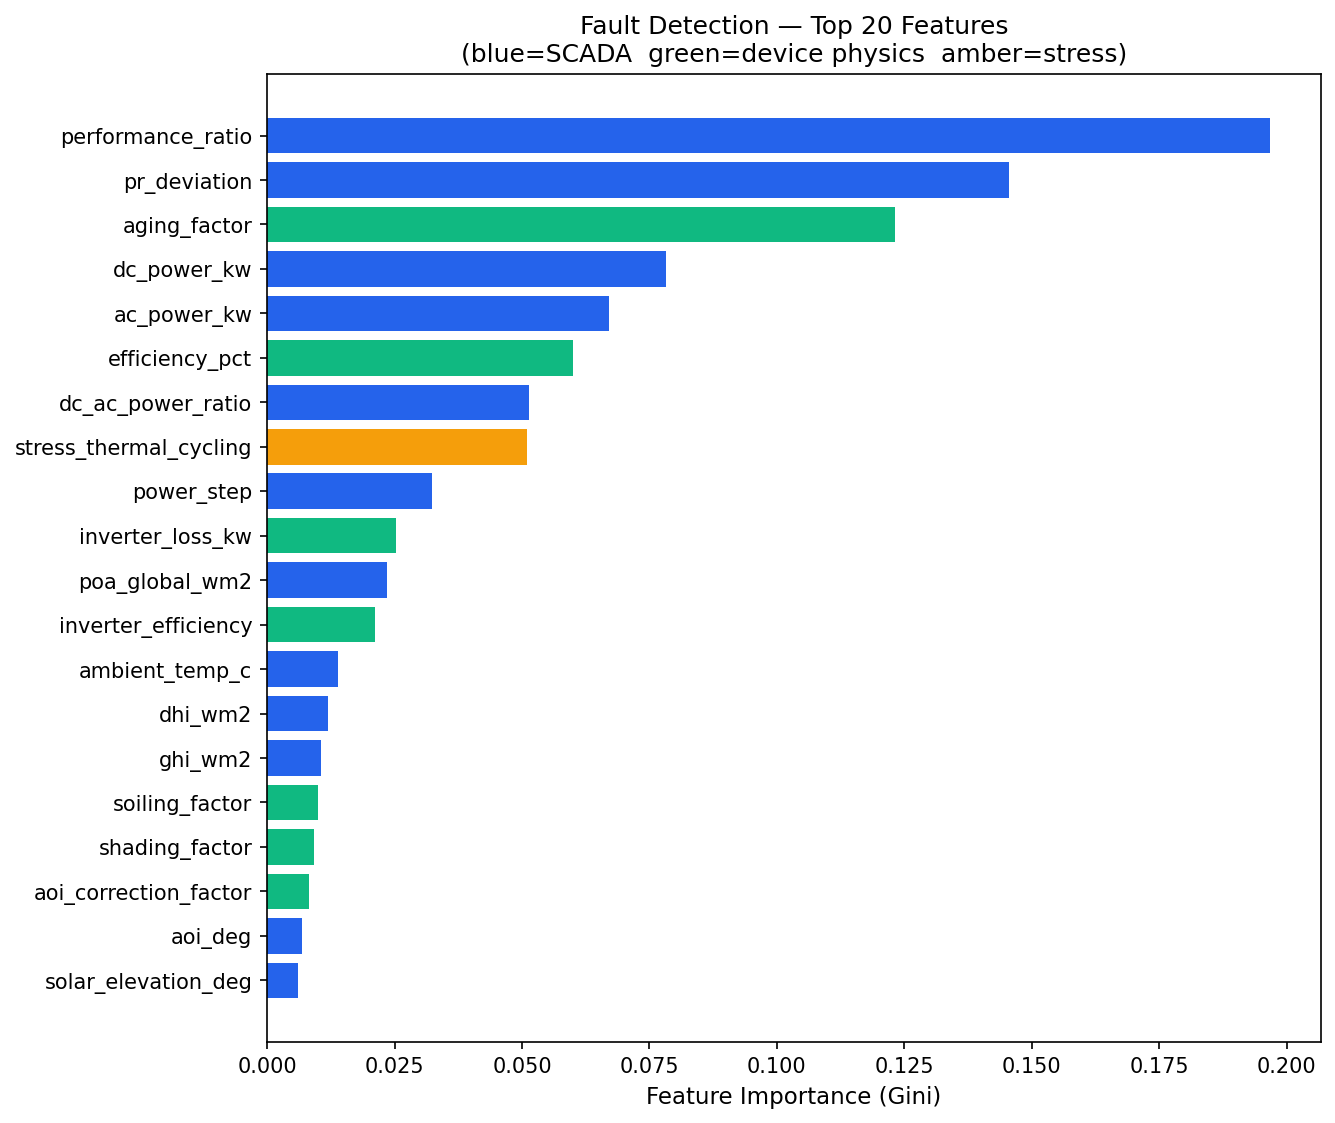

In [5]:
# Feature importance
plot_importance(
    model_det, feature_list,
    "Fault Detection",
    f"{OUTPUT_DIR}/importance_detection.png",
    scada_features=cfg.scada_features,
    device_features=cfg.device_features,
    top_n=20,
)
from IPython.display import Image
Image(f"{OUTPUT_DIR}/importance_detection.png")


## 5. Task 2 — Multi-class Fault Classification

In [6]:
model_cls, auc_cls, cv_cls, le = train_rf_classification(
    df, feature_list, cfg,
    save_path=f"{OUTPUT_DIR}/rf_model_classification.pkl",
    save_deployment_path=f"{OUTPUT_DIR}/rf_deployment_classification.pkl",
)
if auc_cls:
    print(f"\nHold-out Weighted ROC AUC: {auc_cls:.4f}")
    if cv_cls is not None:
        print(f"5-fold CV AUC:             {cv_cls.mean():.4f} ± {cv_cls.std():.4f}")



  RF FAULT CLASSIFICATION (multi-class)
  1,310,872 faulted rows, 11 fault types
  pid                               163,607
  sensor_drift                      163,343
  combo                             163,202
  connector_burnout                 143,820
  solder_fatigue                    143,431
  bypass_diode_short                138,547
  cell_crack                        135,174
  string_failure                    100,294
  mppt_failure                       96,483
  sudden_soiling                     40,602
  curtailment                        22,369
  Training RF (200 trees, 11 classes) …
  Trained in 194.0s

                    precision    recall  f1-score   support

bypass_diode_short       1.00      1.00      1.00     27709
        cell_crack       0.96      0.96      0.96     27035
             combo       0.99      1.00      1.00     32640
 connector_burnout       1.00      0.99      1.00     28764
       curtailment       0.59      0.96      0.73      4474
      mppt_f

  Saved importance_classification.png


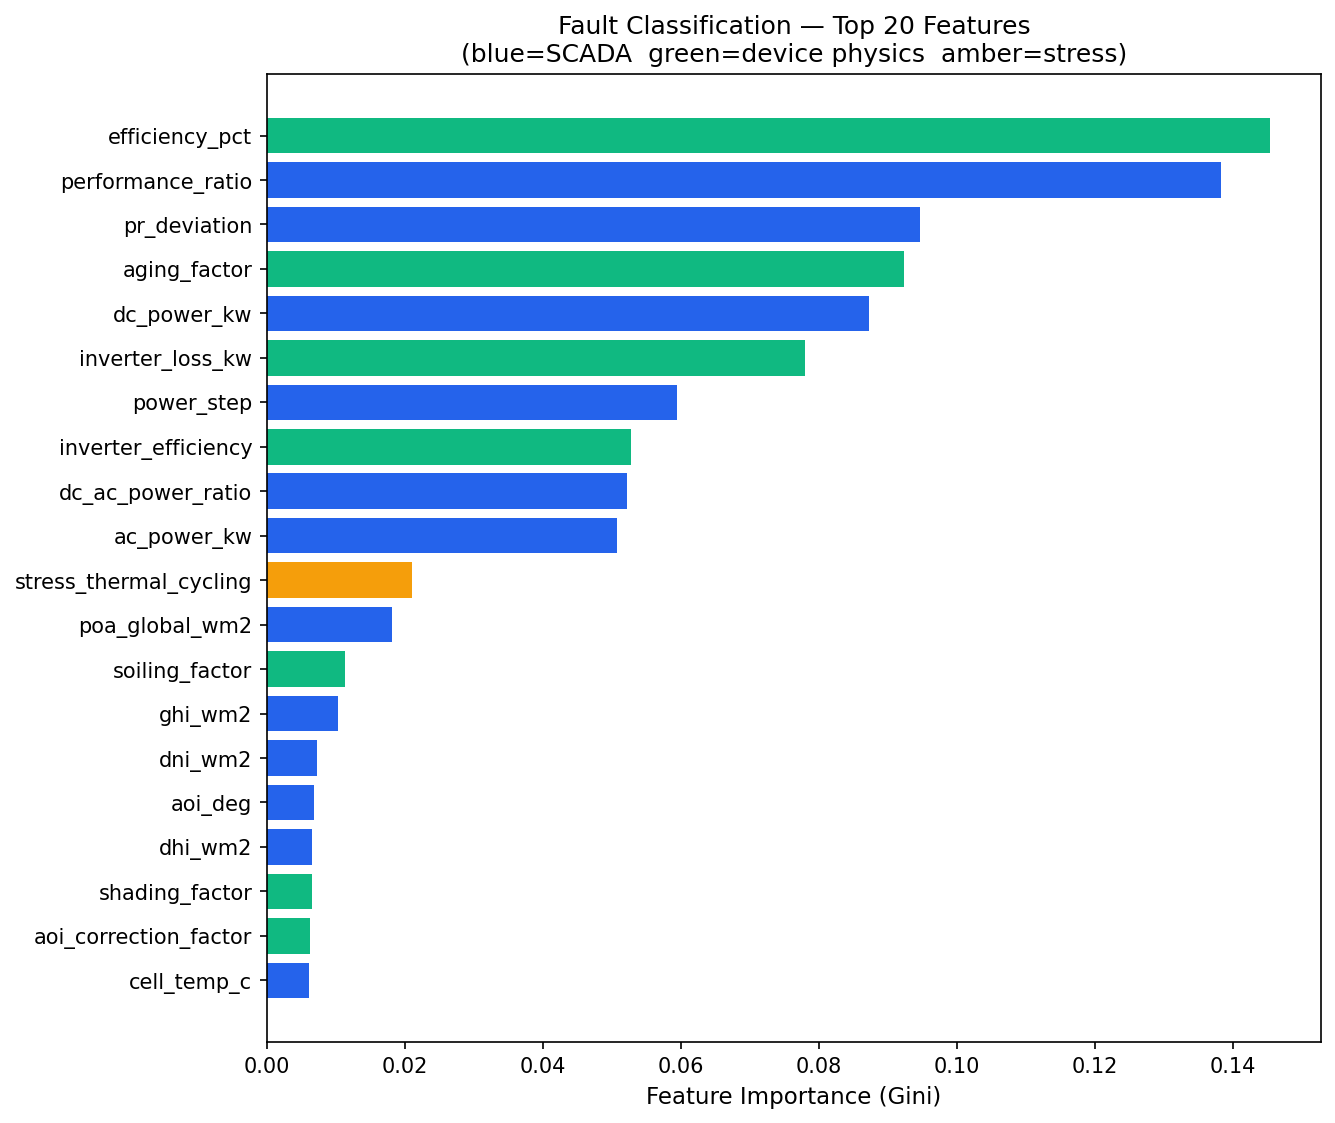

In [7]:
plot_importance(
    model_cls, feature_list,
    "Fault Classification",
    f"{OUTPUT_DIR}/importance_classification.png",
    scada_features=cfg.scada_features,
    device_features=cfg.device_features,
)
Image(f"{OUTPUT_DIR}/importance_classification.png")


## 6. Task 3 — Temporal Robustness

In [8]:
temporal_results = run_temporal_split(df, feature_list, pathlib.Path(OUTPUT_DIR), cfg)
print("\nTemporal split results:")
for k, v in temporal_results.items():
    print(f"  {k}: {v:.4f}")



  TEMPORAL SPLIT (train years 1…N-1, test year N)
  Train: 1,633,253 rows (years 1, 2, 3, 4, 5)
  Test:  325,868 rows (year 6)

  — Detection —
  Trained in 278.4s

              precision    recall  f1-score   support

     Healthy       0.47      0.84      0.61     45737
     Faulted       0.97      0.85      0.90    280131

    accuracy                           0.85    325868
   macro avg       0.72      0.85      0.75    325868
weighted avg       0.90      0.85      0.86    325868

  Temporal Detection AUC: 0.9242
  Saved confusion_temporal_detection.png

  — Classification —

                    precision    recall  f1-score   support

bypass_diode_short       1.00      1.00      1.00     27004
        cell_crack       0.87      0.94      0.90     27007
             combo       1.00      1.00      1.00     27068
 connector_burnout       1.00      1.00      1.00     27456
       curtailment       0.00      0.00      0.00     22369
      mppt_failure       0.69      0.72      0.70

## 7. Task 4 — Cross-Location Generalisation

In [9]:
# Requires data from multiple sites — skip gracefully if only one site
cross_results = run_cross_location(df, feature_list, pathlib.Path(OUTPUT_DIR), cfg)
if cross_results:
    import pandas as pd
    display(pd.DataFrame(cross_results).set_index("test_location"))



  CROSS-LOCATION GENERALISATION (leave-one-site-out)
  Test: Miami                 Det AUC=0.8351  Cls AUC=0.8875  Acc=0.5545
  Test: Phoenix               Det AUC=0.9257  Cls AUC=0.9719  Acc=0.8518
  Test: Los Angeles           Det AUC=0.9225  Cls AUC=0.9754  Acc=0.8413
  Test: Albuquerque           Det AUC=0.9217  Cls AUC=0.9786  Acc=0.8375
  Test: Wichita               Det AUC=0.9161  Cls AUC=0.9776  Acc=0.8308
  Test: Eugene                Det AUC=0.9069  Cls AUC=0.9756  Acc=0.8366
  Saved cross_location.png
  Average Detection AUC:       0.9047
  Average Classification AUC:  0.9611


,test_loc_id,detection_auc,classification_auc,accuracy
test_location,,,,
Miami,25.77_-80.19,0.835059,0.887465,0.554467
Phoenix,33.45_-112.07,0.925749,0.971890,0.851845
Los Angeles,34.05_-118.24,0.922468,0.975442,0.841345
Albuquerque,35.08_-106.65,0.921653,0.978574,0.837486
Wichita,37.69_-97.34,0.916118,0.977616,0.830764
Eugene,44.05_-123.1,0.906910,0.975584,0.836609


## 8. Task 5 — Feature Ablation

In [10]:
ablation_results = run_feature_ablation(df, pathlib.Path(OUTPUT_DIR), cfg)
import pandas as pd
display(pd.DataFrame(ablation_results))



  FEATURE ABLATION
  SCADA only                                     19 feat  AUC=0.9052  (268.8s)
  SCADA + stress (deployment)                    25 feat  AUC=0.9153  (299.3s)
  SCADA + device physics                         27 feat  AUC=0.9278  (324.2s)
  Full (SCADA + physics + stress)                33 feat  AUC=0.9285  (306.9s)
  Delta (Full − SCADA only): +0.0233 AUC
  Saved deployment model: rf_deployment_detection.pkl  (25 features)
  Saved feature_ablation.png


,feature_set,n_features,auc
0,SCADA only,19,0.905155
1,SCADA + stress (deployment),25,0.915330
2,SCADA + device physics,27,0.927793
3,Full (SCADA + physics + stress),33,0.928475


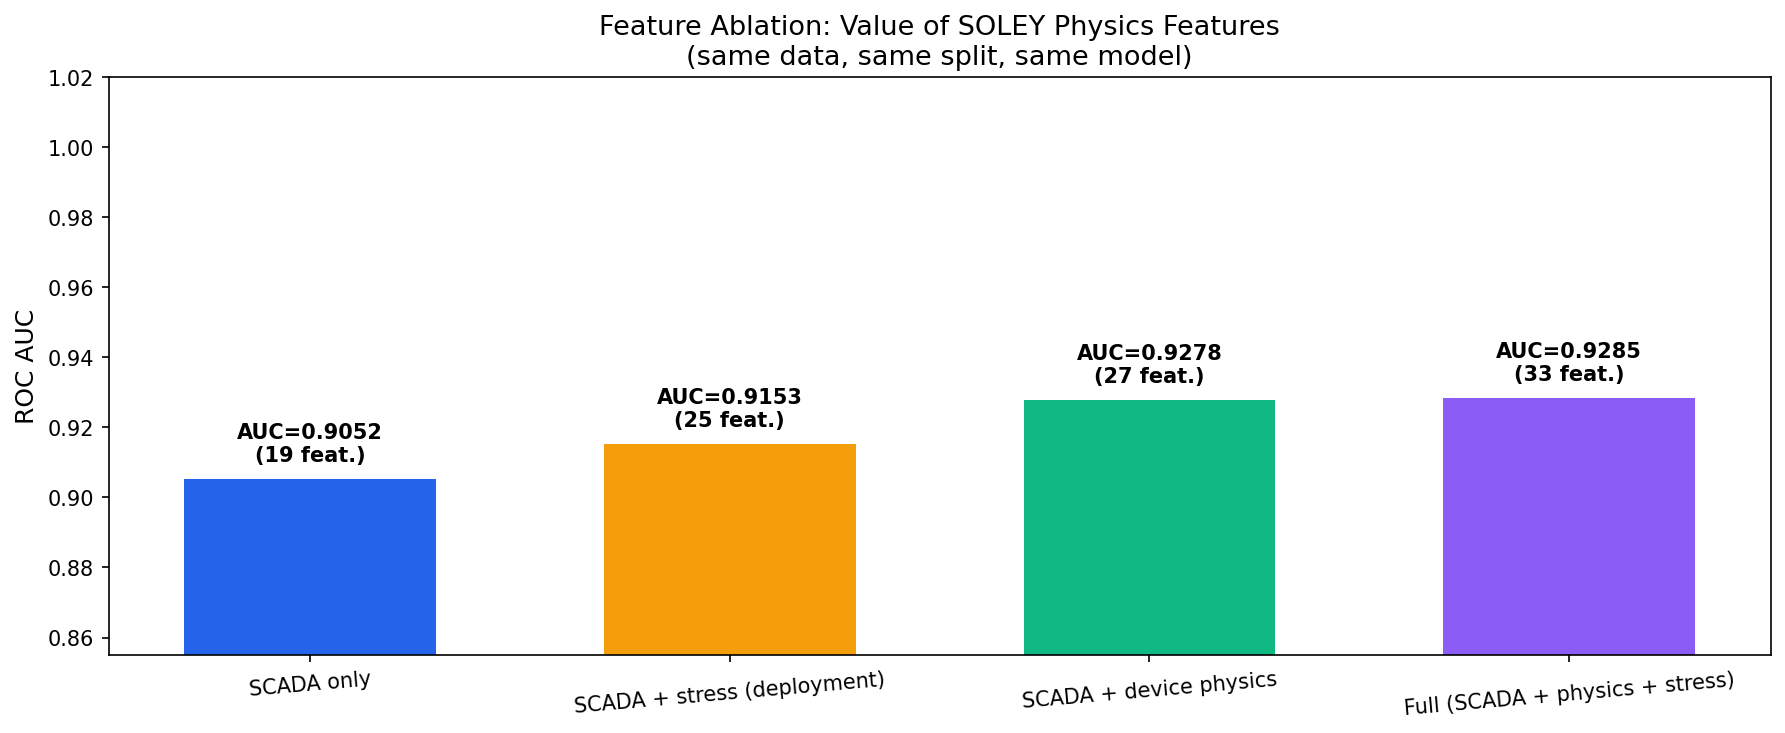

In [11]:
Image(f"{OUTPUT_DIR}/feature_ablation.png")


## 9. Results Summary

In [12]:
print("=" * 55)
print("RANDOM FOREST RESULTS SUMMARY")
print("=" * 55)
print(f"Detection     ROC AUC (hold-out): {auc_det:.4f}")
print(f"Detection     ROC AUC (5-fold CV): {cv_det.mean():.4f} ± {cv_det.std():.4f}")
if auc_cls:
    print(f"Classification ROC AUC (hold-out): {auc_cls:.4f}")
for k, v in temporal_results.items():
    print(f"Temporal {k}:  {v:.4f}")
if cross_results:
    import numpy as np
    avg_d = np.nanmean([r['detection_auc'] for r in cross_results])
    avg_c = np.nanmean([r['classification_auc'] for r in cross_results])
    print(f"Cross-location avg Detection AUC:       {avg_d:.4f}")
    print(f"Cross-location avg Classification AUC: {avg_c:.4f}")
delta = ablation_results[-1]['auc'] - ablation_results[0]['auc']
print(f"Ablation delta (Full - SCADA only):  {delta:+.4f} AUC")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")


RANDOM FOREST RESULTS SUMMARY
Detection     ROC AUC (hold-out): 0.9285
Detection     ROC AUC (5-fold CV): 0.9042 ± 0.0901
Classification ROC AUC (hold-out): 0.9734
Temporal detection_auc:  0.9242
Cross-location avg Detection AUC:       0.9047
Cross-location avg Classification AUC: 0.9611
Ablation delta (Full - SCADA only):  +0.0233 AUC

All outputs saved to: outputs/random_forest
